#  BEM Simulation of the NREL 5MW Wind Turbine (Python Version)

This project guides you through implementing your own **Blade Element Momentum (BEM)** method to simulate the **NREL 5MW Reference Wind Turbine** and compare it to results from **FAST** simulations.

---

## Project Overview

You will:
- Implement BEM logic in Python
- Simulate rotor aerodynamics using BEM and Actuator Disk (AD) models
- Compare your results to the FAST simulation data

---

## Function Description

After uploading `Exercise02.ipynb`, the following scripts and functions in the Python files will be available:

| Scripts and Functions | Description |
|------|-------------|
| `Exercise02.ipynb` | Main script to simulate the wind turbine using SLOW  with different aerodynamics via Euler forward and compares the results to FAST. For the test simulation, an Actuator Disk (AD) approach has been used for the aerodynamics, implemented in Function `Aerodynamics_AD` |
| `NREL5MWParameterSLOW` | Loads all turbine parameters |
| `Aerodynamics_AD` | Contains Actuator Disk (AD) model logic |
| `Aerodynamics_BEM` | **(To be implemented)**: BEM logic |
| `ReadAirfoils` | Reads AeroDyn input files from FAST for BEM|
| `SLOW` | Computes the right-hand side of the ODE's for SLOW |
| `PowerAndThrustCoefficientRegion2NREL5MW.mat` | Contains `c_P` and `c_T` vs `lambda` data for AD |



<div style="color: red; font-weight: bold;">
🔺 Note: Since Colab cannot execute `.exe` files, the `WindStep_08.out` file is provided instead. This contains the output data from the FAST simulation for comparison.
</div>
---

## ✅ Tasks

### Step-by-Step

1. `Run the first cell` to load all the files necessary from github to your colab.
2. Run `all the cells` to generate simulation plots
3. Implement the BEM code in `Aerodynamics_BEM` function in `cell 4` and run it.
4. Switch `Parameter["AeroMode"] = "BEM"` in `cell 5 and line 9`
5. Compare results to AD and FAST outputs

---

## Implementation Hints

### Basic BEM Features

- Iteration of the axial and angular induction factor for the blade sections defined in the AeroDyn input file `RNodes`.  Drag can be ignored as in the example.- Calculation of the aerodynamic thrust and torque for each blade section and for the rotor.
- Aerodynamic damping by considering the tower top speed.

### Advanced Features (Optional)

- Iteration of the axial and angular induction factor considering drag and tip losses.  
- Tilt of the rotor should be considered.

---

## Additional points can be obtained by:
- Code optimization to be close to or faster than the FAST simulation, e.g. use adequate tolerances and useful initial conditions for the induction factors.
- Adjust code such that blade pitch angle changes could be considered (pitch should still be zero).
- Using RK4 (4th order Runge-Kutta method) for simulation.

---

## Group Work

Form groups of up to **5 members**. Discuss your code plan before starting. Clean, commented, and readable code is expected.

---

## Submission & Presentation

- Submit your code before the final lecture
- Present your approach and results

---

Happy coding! 🌀⚡


In [1]:
!git clone https://github.com/WindEnergyEngineering/BEM

Cloning into 'BEM'...
remote: Enumerating objects: 282, done.
remote: Counting objects: 100% (282/282), done.
remote: Compressing objects: 100% (255/255), done.
remote: Total 282 (delta 29), reused 274 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (282/282), 17.49 MiB | 28.34 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [2]:

import numpy as np

def NREL5MWParameterSLOW():
    return {
        'General': {'rho': 1.225},
        'Turbine': {
            'r_GB': 97,
            'R': 126 / 2,
            'J': 44516521,
            'm_eT': 429918.4,
            'k_eT': 1814852,
            'c_eT': 7066.488,
            'x_0T': -0.0138,
            'ShftTilt': np.deg2rad(-5),
        },
        'VSC': {},
    }


def ReadAirfoils(aero_file):
    with open(aero_file, 'r') as f:
        for _ in range(15):
            f.readline()
        num_foil_line = f.readline()
        num_foil = int(num_foil_line.strip().split()[0])
        foil_names = [f.readline().split('"')[1] for _ in range(num_foil)]
        bld_nodes_line = f.readline()
        bld_nodes = int(bld_nodes_line.strip().split()[0])
        f.readline()
        data = np.loadtxt(f, dtype={'names': ('R', 'Twist', 'DR', 'Chord', 'Nfoil', 'dummy'),
                                    'formats': ('f4', 'f4', 'f4', 'f4', 'i4', 'S10')})

    BEM = {
        'NumFoil': num_foil,
        'BldNodes': bld_nodes,
        'RNodes': data['R'],
        'AeroTwst': data['Twist'],
        'DRNodes': data['DR'],
        'Chord': data['Chord'],
        'NFoil': data['Nfoil'],
        'AoA': [],
        'Cl': [],
        'Cd': [],
        'Cm': []
    }

    for foil_file in foil_names:
        airfoil_data = np.loadtxt(foil_file, skiprows=14)
        BEM['AoA'].append(airfoil_data[:, 0])
        BEM['Cl'].append(airfoil_data[:, 1])
        BEM['Cd'].append(airfoil_data[:, 2])
        BEM['Cm'].append(airfoil_data[:, 3])

    return BEM

def SLOW(x, v_0, Parameter):
    J = Parameter['Turbine']['J']
    x_0T = Parameter['Turbine']['x_0T']
    k_eT = Parameter['Turbine']['k_eT']
    m_eT = Parameter['Turbine']['m_eT']
    c_eT = Parameter['Turbine']['c_eT']
    r_GB = Parameter['Turbine']['r_GB']
    k = Parameter['VSC']['k']

    Omega, x_T, x_T_dot = x

    if Parameter['AeroMode'] == 'AD':
        M_a, F_a = Aerodynamics_AD(x, v_0, Parameter)
    elif Parameter['AeroMode'] == 'BEM':
        M_a, F_a = Aerodynamics_BEM(x, v_0, Parameter)
    else:
        raise ValueError(f"Aerodynamics Module {Parameter['AeroMode']} not defined")

    Omega_G = Omega * r_GB
    M_G = k * Omega_G ** 2

    Omega_dot = (M_a - M_G * r_GB) / J
    x_T_ddot = (F_a - c_eT * x_T_dot - k_eT * (x_T - x_0T)) / m_eT

    return np.array([Omega_dot, x_T_dot, x_T_ddot])


In [3]:

def Aerodynamics_AD(x, v_0, Parameter):
    R = Parameter['Turbine']['R']
    rho = Parameter['General']['rho']
    Omega = x[0]
    x_T_dot = x[2]

    v_rel = v_0 - x_T_dot
    lam = Omega * R / v_rel
    c_P = np.interp(lam, Parameter['AD']['lambda'], Parameter['AD']['c_P'])
    c_T = np.interp(lam, Parameter['AD']['lambda'], Parameter['AD']['c_T'])

    M_a = 0.5 * rho * np.pi * R ** 3 * c_P / lam * v_rel ** 2
    F_a = 0.5 * rho * np.pi * R ** 2 * c_T * v_rel ** 2

    return M_a, F_a

In [4]:
# This is a placeholder function. You need to implement the actual BEM method.
def Aerodynamics_BEM(x, v_0, Parameter):
    return np.nan, np.nan

Time Ratio SLOW (Sim/CPU): 409.1172


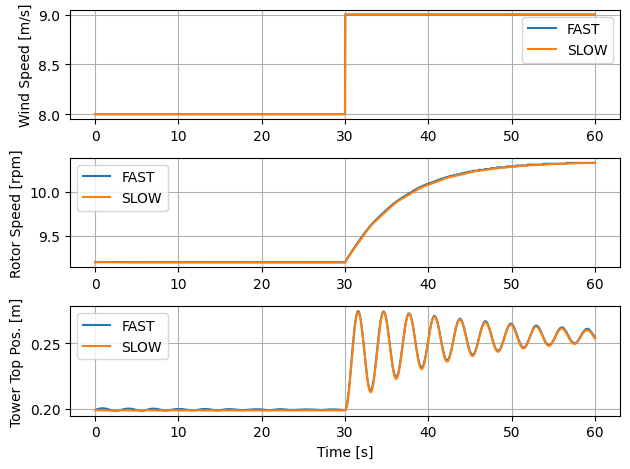

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.io import loadmat
from scipy.interpolate import interp1d

# Preprocessing SLOW
Parameter = NREL5MWParameterSLOW()
Parameter['VSC']['k'] = 2.3323
Parameter['AeroMode'] = 'AD'
AD_data = loadmat('BEM/PowerAndThrustCoefficientRegion2NREL5MW.mat')
Parameter['AD'] = {
    'c_P': AD_data['c_P'].flatten(),
    'c_T': AD_data['c_T'].flatten(),
    'lambda': AD_data['lambda'].flatten()
}
AeroFile = 'BEM/WindStep_08_AeroFile.dat'
BEM = ReadAirfoils(AeroFile)

# Simulation parameters
dt = 0.0125
TMax = 60
t = np.arange(0, TMax + dt, dt)
n = len(t)

# Wind disturbance
v_0 = np.interp(t, [0, 30, 30 + dt, 120], [8, 8, 9, 9])

# Initial conditions
x = np.full((n, 3), np.nan)
x[0, 0] = 9.196 / 60 * 2 * np.pi
x[0, 1] = 0.199
x[0, 2] = 0.0

# SLOW simulation
start_time = time.time()
for k in range(n - 1):
    x_dot_k = SLOW(x[k, :], v_0[k], Parameter)
    x[k + 1, :] = x[k, :] + dt * x_dot_k
TimeRatio = TMax / (time.time() - start_time)

# Postprocessing
Omega = x[:, 0]
x_T = x[:, 1]

# FAST Processing (pseudo)
data = np.loadtxt('BEM/WindStep_08.out', skiprows=8, encoding='latin-1')
Time = data[:, 0]
Wind1VelX = data[:, 1]
RotSpeed = data[:, 3]
TTDspFA = data[:, 4]

# Plot
print(f"Time Ratio SLOW (Sim/CPU): {TimeRatio:.4f}")

plt.figure()

plt.subplot(3, 1, 1)
plt.plot(Time, Wind1VelX, label='FAST')
plt.plot(t, v_0, label='SLOW')
plt.grid()
plt.ylabel('Wind Speed [m/s]')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(Time, RotSpeed, label='FAST')
plt.plot(t, Omega / (2 * np.pi) * 60, label='SLOW')
plt.grid()
plt.ylabel('Rotor Speed [rpm]')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(Time, TTDspFA, label='FAST')
plt.plot(t, x_T, label='SLOW')
plt.grid()
plt.xlabel('Time [s]')
plt.ylabel('Tower Top Pos. [m]')
plt.legend()

plt.tight_layout()
plt.show()
